# 01 — CEO Mention Coverage Report

**Purpose:** Analyze the frequency of CEO mentions in filtered Reddit data to determine which CEO-company-year combinations have sufficient data for the self-presentation discrepancy study.

**Key questions:**
- How many mentions does each CEO have per year (during their tenure)?
- Which CEO-years meet the minimum 20-mention threshold?
- What is the usable sample size for the study?
- How does coverage vary across years (Reddit growth bias)?

**Runs on:** Local Python or Google Colab

## Setup

In [6]:
import sys
from pathlib import Path

# Detect environment
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive, files
    drive.mount("/content/drive")
    # Adjust this path to where you upload/store data on Drive
    DATA_ROOT = Path("/content/drive/MyDrive/ceo_reddit/data")
    print("Running on Google Colab")
else:
    # Local: navigate to project root
    PROJECT_ROOT = Path.cwd()
    # Handle running from notebooks/ subdirectory
    if PROJECT_ROOT.name == "corpus_analysis" or PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
        if PROJECT_ROOT.name == "notebooks":
            PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_ROOT = PROJECT_ROOT / "data"
    print(f"Running locally — data root: {DATA_ROOT}")

FILTERED_DIR = DATA_ROOT / "filtered"
PROCESSED_DIR = DATA_ROOT / "processed"
REPORTS_DIR = DATA_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

assert FILTERED_DIR.exists(), f"Filtered data not found at {FILTERED_DIR}"
assert PROCESSED_DIR.exists(), f"Processed data not found at {PROCESSED_DIR}"
print(f"Filtered data: {FILTERED_DIR}")
print(f"Processed data: {PROCESSED_DIR}")

Running locally — data root: /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data
Filtered data: /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data/filtered
Reference data: /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data/reference


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

## Step 1 — Load Data

In [8]:
# Load CEO universe (tenure info)
ceo_df = pd.read_parquet(PROCESSED_DIR / "ceo_universe.parquet")
print(f"CEO universe: {len(ceo_df)} rows, {ceo_df['execid'].nunique()} unique CEOs, {ceo_df['company'].nunique()} companies")
ceo_df.head(3)

CEO universe: 1193 rows, 1172 unique CEOs, 499 companies


,execid,company,first_name,middle_name,last_name,full_name,gender,ceo_start_date,ceo_end_date,ticker,first_year_in_data,last_year_in_data
0,29227,UNITED PARCEL SERVICE INC,David,P.,Abney,David P. Abney,MALE,2014-09-01,2020-06-01,UPS,2015,2019
1,57016,KRAFT HEINZ CO,Carlos,A.,Abrams-Rivera,Carlos A. Abrams-Rivera,MALE,2023-12-01,2026-01-01,KHC,2024,2024
2,17946,COPART INC,A.,Jayson,Adair,A. Jayson Adair,MALE,2010-02-01,2024-04-01,CPRT,2011,2022


In [9]:
# Load filtered Reddit mentions (all parquet partitions)
# Read files individually with fastparquet to avoid hive partitioning schema conflicts
parquet_files = sorted(FILTERED_DIR.rglob("*.parquet"))
print(f"Found {len(parquet_files)} parquet files")

if not parquet_files:
    raise FileNotFoundError("No parquet files found. Is Step 3 filtering complete?")

dfs = []
for f in parquet_files:
    try:
        dfs.append(pd.read_parquet(f, engine="fastparquet"))
    except Exception as e:
        print(f"  Skipping {f.name}: {e}")

mentions_df = pd.concat(dfs, ignore_index=True)
del dfs  # free memory

print(f"Total mentions loaded: {len(mentions_df):,}")
print(f"Columns: {mentions_df.columns.tolist()}")
mentions_df.head(3)

Found 790 parquet files
Total mentions loaded: 194,997
Columns: ['comment_id', 'parent_id', 'subreddit', 'author', 'timestamp', 'year', 'full_text', 'post_title', 'score', 'is_submission', 'execid', 'ceo_matched', 'company_matched', 'ticker_matched', 'match_type', 'match_variant']


,comment_id,parent_id,subreddit,author,timestamp,year,full_text,post_title,score,is_submission,execid,ceo_matched,company_matched,ticker_matched,match_type,match_variant
0,2t0fy,,business,sophia312,1190657672,2007,Happy Days Are Not Here Again: Legendary Inves...,Happy Days Are Not Here Again: Legendary Inves...,1,True,784,James E. Rogers,DUKE ENERGY CORP,DUK,nickname_last,Jim Rogers
1,2twn6,,business,usmanzali,1190847036,2007,Bill Gates vs. Steve Jobs,Bill Gates vs. Steve Jobs,0,True,14302,Steven P. Jobs,APPLE INC,AAPL,nickname_last,Steve Jobs
2,2vrjk,,business,128bit,1191342895,2007,Jim Rogers Warns of Fallout From Fed Cuts; Say...,Jim Rogers Warns of Fallout From Fed Cuts; Say...,3,True,784,James E. Rogers,DUKE ENERGY CORP,DUK,nickname_last,Jim Rogers


In [10]:
# Quick data health check
print(f"Year range: {mentions_df['year'].min()} - {mentions_df['year'].max()}")
print(f"Unique CEOs mentioned (execid): {mentions_df['execid'].nunique()}")
print(f"Unique subreddits: {mentions_df['subreddit'].nunique()}")
print(f"Submissions vs comments: {mentions_df['is_submission'].value_counts().to_dict()}")
print(f"\nMatch type distribution:")
print(mentions_df["match_type"].value_counts().to_string())

Year range: 2007 - 2025
Unique CEOs mentioned (execid): 775
Unique subreddits: 75
Submissions vs comments: {False: 145296, True: 49701}

Match type distribution:
match_type
first_last              114608
nickname_last            44007
company_ceo              14368
full_name                 7576
ceo_of_company            6787
company_ceo_short         4458
ceo_of_company_short      3057
last_first                 136


## Step 2 — Build CEO Tenure Lookup

We need to know each CEO's active years so we only count mentions during their tenure. A mention of "Steve Jobs" in 2023 is noise, not signal.

In [11]:
# Build tenure year ranges per CEO
# first_year_in_data / last_year_in_data from ExecuComp tells us when they were active as CEO
tenure = ceo_df[["execid", "full_name", "company", "ticker",
                  "first_year_in_data", "last_year_in_data"]].copy()

# Expand to one row per CEO-year during tenure
tenure_years = []
for _, row in tenure.iterrows():
    for yr in range(int(row["first_year_in_data"]), int(row["last_year_in_data"]) + 1):
        tenure_years.append({
            "execid": row["execid"],
            "full_name": row["full_name"],
            "company": row["company"],
            "ticker": row["ticker"],
            "year": yr,
        })

tenure_yr_df = pd.DataFrame(tenure_years)
print(f"Total CEO-company-year slots: {len(tenure_yr_df):,}")
print(f"Year range in tenure data: {tenure_yr_df['year'].min()} - {tenure_yr_df['year'].max()}")

Total CEO-company-year slots: 7,238
Year range in tenure data: 2010 - 2025


## Step 3 — Count Mentions per CEO-Company-Year

In [12]:
# Count mentions per execid per year from Reddit data
mention_counts = (
    mentions_df
    .groupby(["execid", "year"])
    .agg(
        mention_count=("comment_id", "count"),
        unique_subreddits=("subreddit", "nunique"),
        unique_authors=("author", "nunique"),
        submission_count=("is_submission", "sum"),
    )
    .reset_index()
)
mention_counts["comment_count"] = mention_counts["mention_count"] - mention_counts["submission_count"]

print(f"CEO-year combinations with at least 1 mention: {len(mention_counts):,}")
mention_counts.head()

CEO-year combinations with at least 1 mention: 4,431


,execid,year,mention_count,unique_subreddits,unique_authors,submission_count,comment_count
0,13,2008,1,1,1,1,0
1,13,2016,1,1,1,1,0
2,125,2007,4,1,4,4,0
3,125,2008,294,5,79,291,3
4,125,2009,74,6,44,68,6


In [13]:
# Join with tenure to get the full picture (including zero-mention years)
coverage = tenure_yr_df.merge(
    mention_counts,
    on=["execid", "year"],
    how="left",
)
coverage["mention_count"] = coverage["mention_count"].fillna(0).astype(int)
coverage["unique_subreddits"] = coverage["unique_subreddits"].fillna(0).astype(int)
coverage["unique_authors"] = coverage["unique_authors"].fillna(0).astype(int)

# Flag usable CEO-years (>= 20 mentions)
MIN_MENTIONS = 20
coverage["usable"] = coverage["mention_count"] >= MIN_MENTIONS

print(f"Total CEO-company-year slots: {len(coverage):,}")
print(f"Slots with >= {MIN_MENTIONS} mentions (usable): {coverage['usable'].sum():,} ({coverage['usable'].mean():.1%})")
print(f"Slots with zero mentions: {(coverage['mention_count'] == 0).sum():,}")

Total CEO-company-year slots: 7,238
Slots with >= 20 mentions (usable): 351 (4.8%)
Slots with zero mentions: 5,369


## Step 4 — Coverage by Year

Reddit grew massively over 2010-2025. Early years will have thinner coverage.

In [14]:
yearly = coverage.groupby("year").agg(
    total_slots=("execid", "count"),
    usable_slots=("usable", "sum"),
    total_mentions=("mention_count", "sum"),
    median_mentions=("mention_count", "median"),
).reset_index()
yearly["usable_pct"] = (yearly["usable_slots"] / yearly["total_slots"] * 100).round(1)

print(yearly.to_string(index=False))

 year  total_slots  usable_slots  total_mentions  median_mentions  usable_pct
 2010          441             7            1638              0.0         1.6
 2011          450            10            3799              0.0         2.2
 2012          455            11            1481              0.0         2.4
 2013          466            17            2494              0.0         3.6
 2014          468            22           11720              0.0         4.7
 2015          475            26           10263              0.0         5.5
 2016          480            29            7667              0.0         6.0
 2017          483            19            7167              0.0         3.9
 2018          485            17            7600              0.0         3.5
 2019          490            22            7411              0.0         4.5
 2020          500            25            8460              0.0         5.0
 2021          496            35           14958              0.

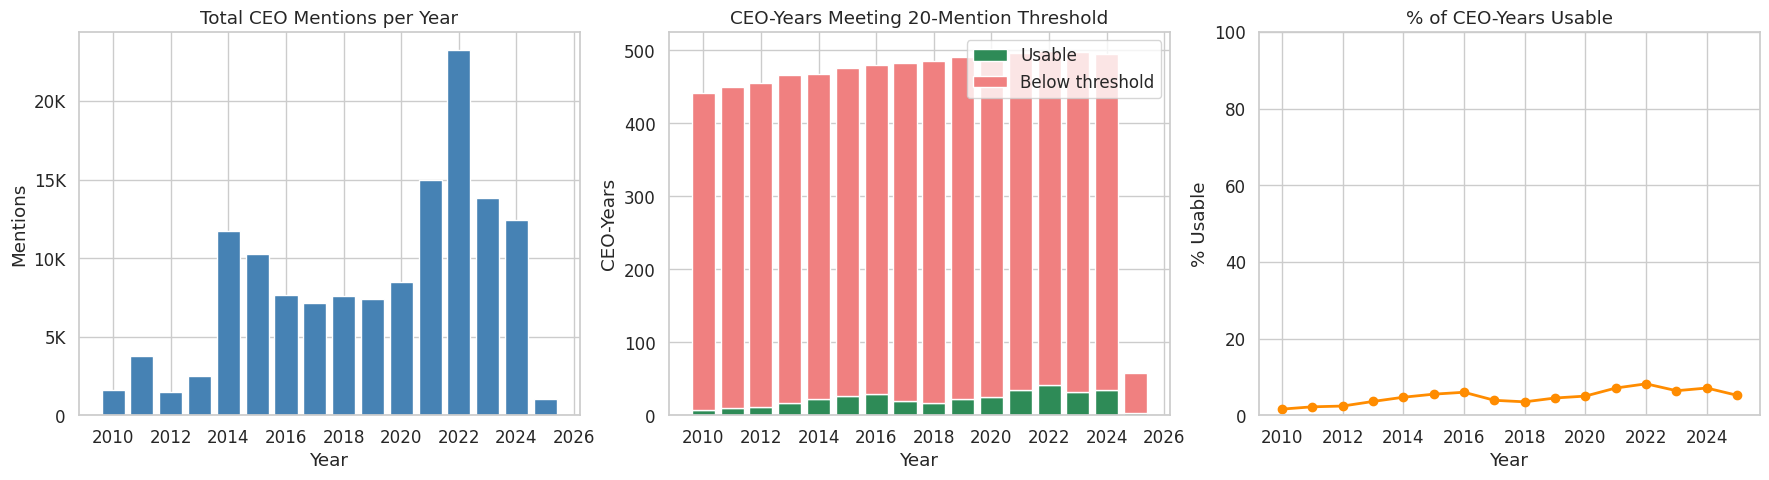

Saved to /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data/reports/coverage_by_year.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total mentions per year
axes[0].bar(yearly["year"], yearly["total_mentions"], color="steelblue")
axes[0].set_title("Total CEO Mentions per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mentions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))

# Usable CEO-years per year
axes[1].bar(yearly["year"], yearly["usable_slots"], color="seagreen", label="Usable")
axes[1].bar(yearly["year"], yearly["total_slots"] - yearly["usable_slots"],
            bottom=yearly["usable_slots"], color="lightcoral", label="Below threshold")
axes[1].set_title(f"CEO-Years Meeting {MIN_MENTIONS}-Mention Threshold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("CEO-Years")
axes[1].legend()

# Usable percentage
axes[2].plot(yearly["year"], yearly["usable_pct"], marker="o", color="darkorange", linewidth=2)
axes[2].set_title("% of CEO-Years Usable")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("% Usable")
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "coverage_by_year.png", bbox_inches="tight")
plt.show()
print(f"Saved to {REPORTS_DIR / 'coverage_by_year.png'}")

## Step 5 — Top and Bottom CEOs by Mention Volume

In [16]:
# Aggregate across all tenure years per CEO
ceo_totals = (
    coverage
    .groupby(["execid", "full_name", "company", "ticker"])
    .agg(
        tenure_years=("year", "count"),
        total_mentions=("mention_count", "sum"),
        usable_years=("usable", "sum"),
        avg_mentions_per_year=("mention_count", "mean"),
    )
    .reset_index()
    .sort_values("total_mentions", ascending=False)
)
ceo_totals["avg_mentions_per_year"] = ceo_totals["avg_mentions_per_year"].round(1)
ceo_totals["usable_pct"] = (ceo_totals["usable_years"] / ceo_totals["tenure_years"] * 100).round(1)

print("=== TOP 25 CEOs by Total Mentions ===")
print(ceo_totals.head(25)[["full_name", "company", "tenure_years",
                            "total_mentions", "usable_years", "avg_mentions_per_year"]].to_string(index=False))
print(f"\n=== BOTTOM 25 CEOs (with at least 1 mention) ===")
has_mentions = ceo_totals[ceo_totals["total_mentions"] > 0].tail(25)
print(has_mentions[["full_name", "company", "tenure_years",
                     "total_mentions", "usable_years", "avg_mentions_per_year"]].to_string(index=False))

zero_mention_ceos = ceo_totals[ceo_totals["total_mentions"] == 0]
print(f"\nCEOs with ZERO mentions: {len(zero_mention_ceos)}")
if len(zero_mention_ceos) > 0 and len(zero_mention_ceos) <= 30:
    print(zero_mention_ceos[["full_name", "company", "tenure_years"]].to_string(index=False))

=== TOP 25 CEOs by Total Mentions ===
             full_name                company  tenure_years  total_mentions  usable_years  avg_mentions_per_year
          Elon R. Musk              TESLA INC            15           51190            13                 3412.7
     Warren E. Buffett     BERKSHIRE HATHAWAY            15           13953            15                  930.2
   Michael Allen Brown        GEN DIGITAL INC             2           12131             2                 6065.5
            Lisa T. Su ADVANCED MICRO DEVICES            10           11656            10                 1165.6
       Timothy D. Cook              APPLE INC            14            8775            14                  626.8
Mark Elliot Zuckerberg     META PLATFORMS INC            14            5019            14                  358.5
        Steven P. Jobs              APPLE INC             2            4078             2                 2039.0
        John J. Legere        T-MOBILE US INC             

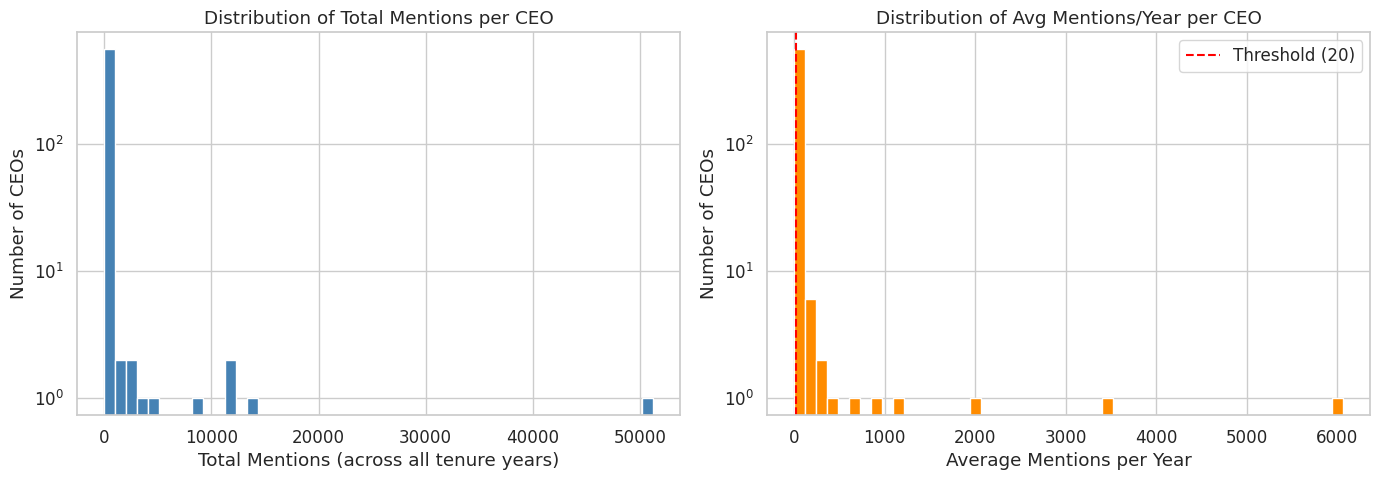

In [17]:
# Distribution of mentions per CEO (log scale — will be heavily skewed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

has_data = ceo_totals[ceo_totals["total_mentions"] > 0]

axes[0].hist(has_data["total_mentions"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Total Mentions per CEO")
axes[0].set_xlabel("Total Mentions (across all tenure years)")
axes[0].set_ylabel("Number of CEOs")
axes[0].set_yscale("log")

axes[1].hist(has_data["avg_mentions_per_year"], bins=50, color="darkorange", edgecolor="white")
axes[1].axvline(x=MIN_MENTIONS, color="red", linestyle="--", label=f"Threshold ({MIN_MENTIONS})")
axes[1].set_title("Distribution of Avg Mentions/Year per CEO")
axes[1].set_xlabel("Average Mentions per Year")
axes[1].set_ylabel("Number of CEOs")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "mention_distribution.png", bbox_inches="tight")
plt.show()

## Step 6 — Coverage Heatmap (Top 50 CEOs)

Rows = CEOs (sorted by total mentions), columns = years. Shows where data exists and where gaps are. Gray = not CEO that year.

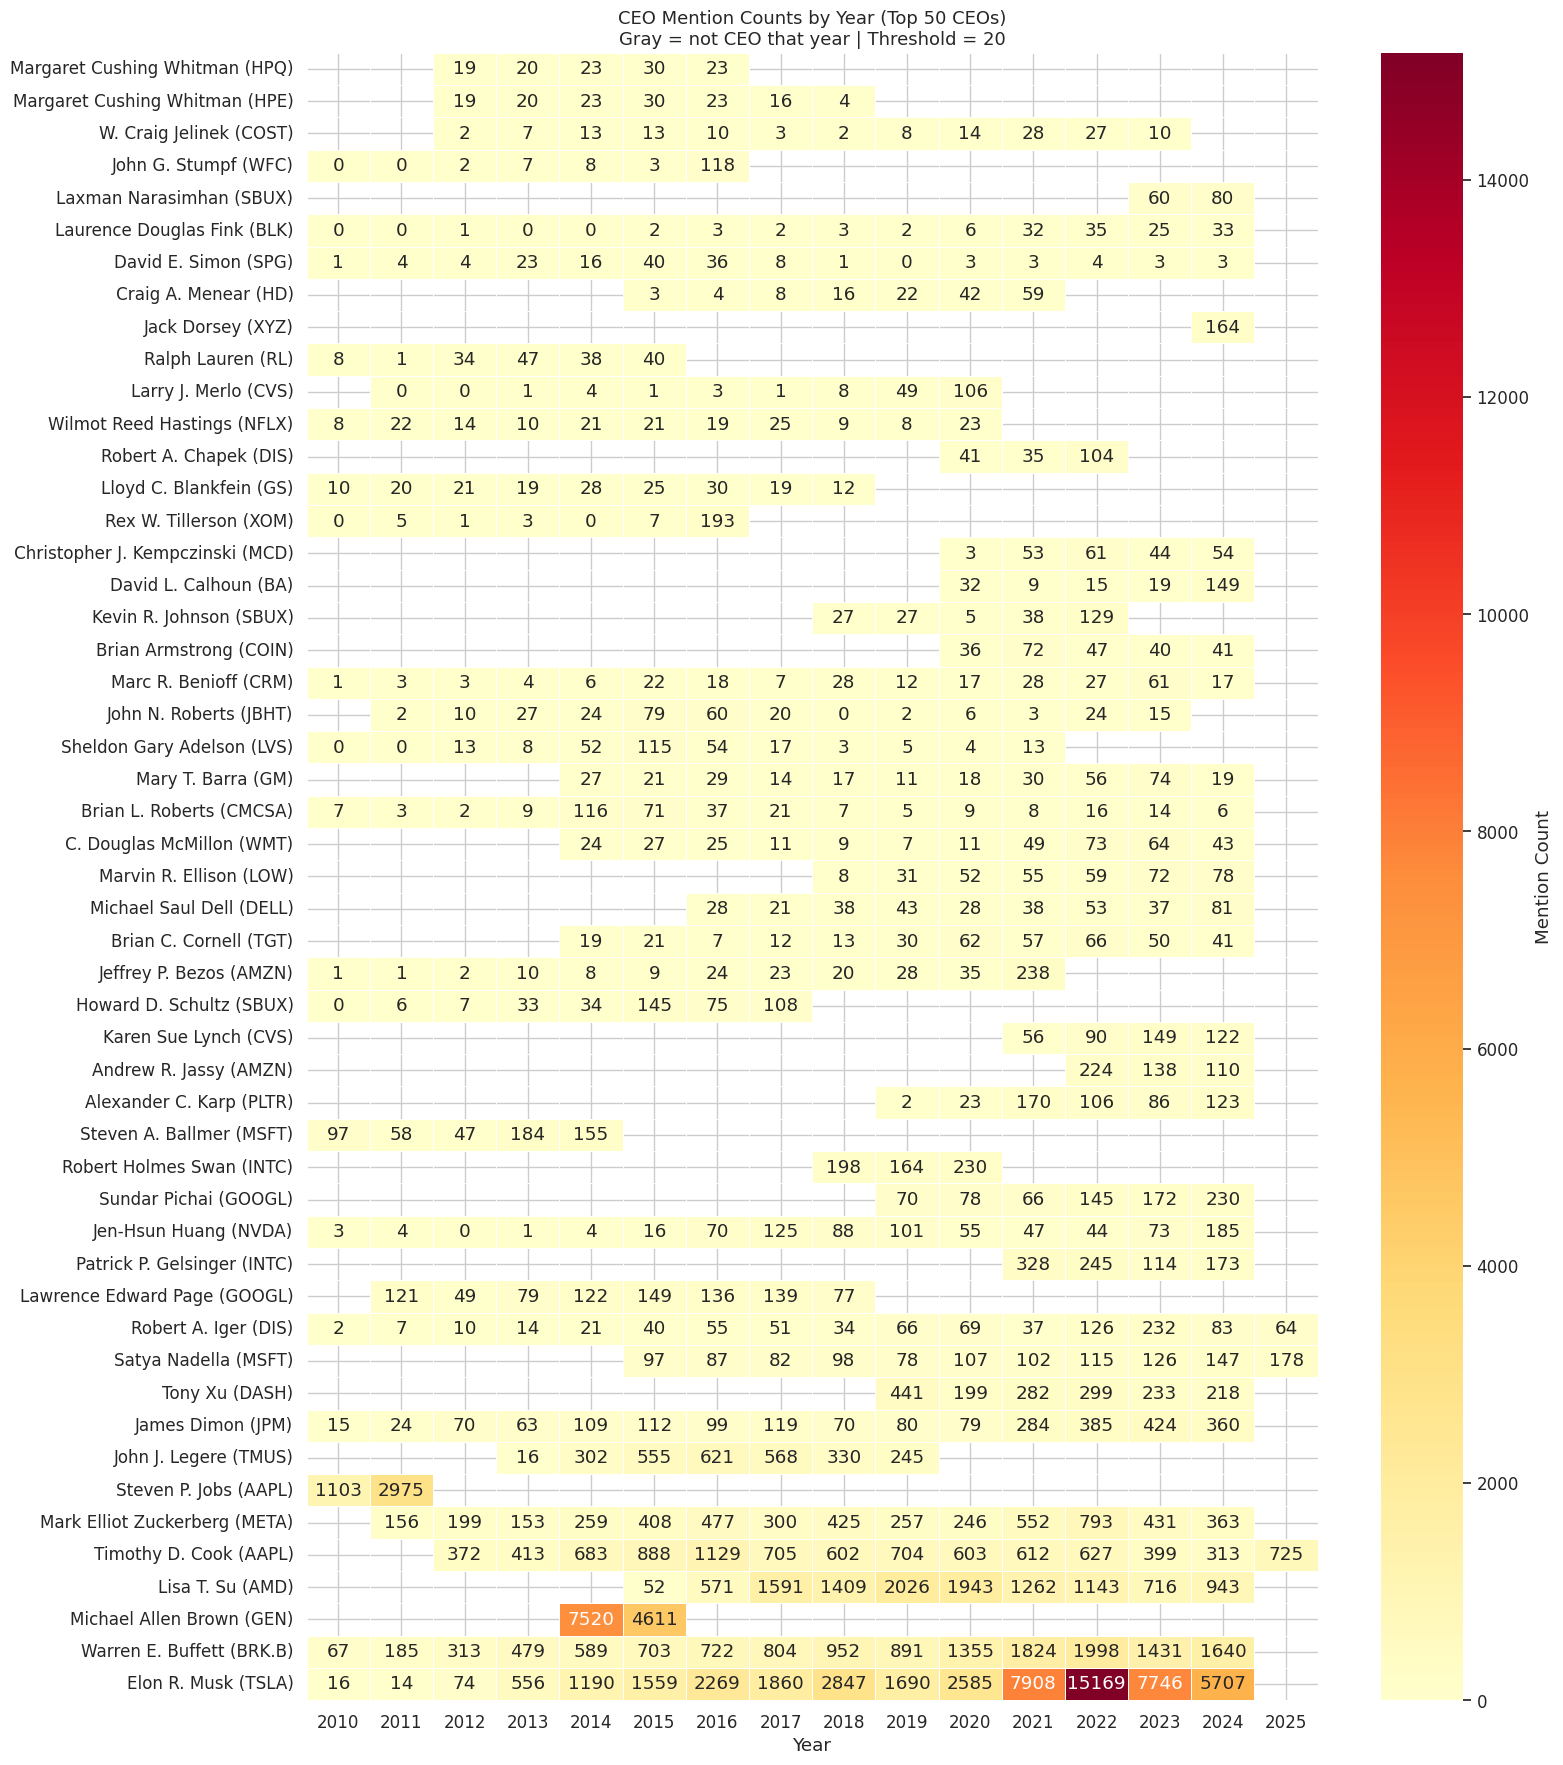

In [18]:
import numpy as np

# Take top 50 CEOs by total mentions for readability
top_ceos = ceo_totals.head(50)["execid"].tolist()
heatmap_data = coverage[coverage["execid"].isin(top_ceos)].copy()

# Create label: "CEO Name (Company)"
heatmap_data["label"] = heatmap_data["full_name"] + " (" + heatmap_data["ticker"] + ")"

# Pivot to matrix
pivot = heatmap_data.pivot_table(
    index="label", columns="year", values="mention_count", aggfunc="sum"
)

# Sort by total mentions descending
pivot["_total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("_total", ascending=True).drop(columns="_total")

fig, ax = plt.subplots(figsize=(16, max(12, len(pivot) * 0.35)))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Mention Count"},
    mask=pivot.isna(),
    ax=ax,
)
ax.set_title(f"CEO Mention Counts by Year (Top 50 CEOs)\nGray = not CEO that year | Threshold = {MIN_MENTIONS}", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "coverage_heatmap_top50.png", bbox_inches="tight")
plt.show()

## Step 7 — Match Type Breakdown per CEO-Year

Name-based matches ("Tim Cook") are unambiguous. "Company CEO" matches during transitions could be noisy.

In [19]:
match_type_counts = (
    mentions_df
    .groupby(["year", "match_type"])
    .size()
    .reset_index(name="count")
)

match_pivot = match_type_counts.pivot_table(
    index="year", columns="match_type", values="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
match_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Mention Match Types by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Mentions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax.legend(title="Match Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "match_types_by_year.png", bbox_inches="tight")
plt.show()

KeyboardInterrupt: 

In [ ]:
# Per-CEO match type composition (are some CEOs only found via "Company CEO"?)
ceo_match_types = (
    mentions_df
    .groupby(["execid", "ceo_matched", "match_type"])
    .size()
    .reset_index(name="count")
)

# Flag CEOs where >80% of matches are company-title patterns (higher ambiguity risk)
ceo_match_totals = ceo_match_types.groupby("execid")["count"].sum().reset_index(name="total")
company_patterns = ["ceo_of_company", "company_ceo", "ceo_of_company_short", "company_ceo_short"]
ceo_company_matches = (
    ceo_match_types[ceo_match_types["match_type"].isin(company_patterns)]
    .groupby("execid")["count"].sum()
    .reset_index(name="company_pattern_count")
)
ambiguity = ceo_match_totals.merge(ceo_company_matches, on="execid", how="left")
ambiguity["company_pattern_count"] = ambiguity["company_pattern_count"].fillna(0)
ambiguity["company_pct"] = (ambiguity["company_pattern_count"] / ambiguity["total"] * 100).round(1)
ambiguity = ambiguity.merge(ceo_df[["execid", "full_name", "company"]].drop_duplicates("execid"), on="execid")

high_ambiguity = ambiguity[ambiguity["company_pct"] > 80].sort_values("total", ascending=False)
print(f"CEOs where >80% of matches come from company-title patterns ({len(high_ambiguity)}):")
print(high_ambiguity[["full_name", "company", "total", "company_pct"]].head(20).to_string(index=False))

## Step 8 — Subreddit Concentration

Is a CEO's signal coming from one subreddit (risky) or spread across many (robust)?

In [ ]:
subreddit_spread = (
    mentions_df
    .groupby(["execid", "ceo_matched"])
    .agg(
        total_mentions=("comment_id", "count"),
        n_subreddits=("subreddit", "nunique"),
        top_subreddit=("subreddit", lambda x: x.value_counts().index[0]),
        top_subreddit_pct=("subreddit", lambda x: x.value_counts().iloc[0] / len(x) * 100),
    )
    .reset_index()
    .sort_values("total_mentions", ascending=False)
)
subreddit_spread["top_subreddit_pct"] = subreddit_spread["top_subreddit_pct"].round(1)

print("=== Subreddit Concentration (Top 30 CEOs) ===")
print(subreddit_spread.head(30)[["ceo_matched", "total_mentions", "n_subreddits",
                                  "top_subreddit", "top_subreddit_pct"]].to_string(index=False))

print(f"\n=== CEOs with mentions from only 1 subreddit ===")
single_sub = subreddit_spread[subreddit_spread["n_subreddits"] == 1]
print(f"Count: {len(single_sub)}")
if len(single_sub) <= 20:
    print(single_sub[["ceo_matched", "total_mentions", "top_subreddit"]].to_string(index=False))

## Step 9 — Final Usability Summary

In [ ]:
total_ceo_years = len(coverage)
usable_ceo_years = coverage["usable"].sum()
total_ceos = coverage["execid"].nunique()
usable_ceos = coverage[coverage["usable"]]["execid"].nunique()
total_companies = coverage["company"].nunique()
usable_companies = coverage[coverage["usable"]]["company"].nunique()

# Study window is 2012-2025
study_window = coverage[(coverage["year"] >= 2012) & (coverage["year"] <= 2025)]
study_usable = study_window[study_window["usable"]]

print("=" * 60)
print("CORPUS USABILITY SUMMARY")
print("=" * 60)
print(f"")
print(f"ALL YEARS ({coverage['year'].min()}-{coverage['year'].max()})")
print(f"  Total CEO-company-year slots:  {total_ceo_years:,}")
print(f"  Usable (>= {MIN_MENTIONS} mentions):       {usable_ceo_years:,} ({usable_ceo_years/total_ceo_years:.1%})")
print(f"  Unique CEOs with data:         {usable_ceos} of {total_ceos}")
print(f"  Unique companies with data:    {usable_companies} of {total_companies}")
print(f"")
print(f"STUDY WINDOW (2012-2025)")
print(f"  Total CEO-company-year slots:  {len(study_window):,}")
print(f"  Usable (>= {MIN_MENTIONS} mentions):       {len(study_usable):,} ({len(study_usable)/len(study_window):.1%})")
print(f"  Unique CEOs:                   {study_usable['execid'].nunique()}")
print(f"  Unique companies:              {study_usable['company'].nunique()}")
print(f"  Total mentions in window:      {study_window['mention_count'].sum():,}")
print(f"")
print(f"MEDIAN MENTIONS PER USABLE CEO-YEAR: {study_usable['mention_count'].median():.0f}")
print(f"P25: {study_usable['mention_count'].quantile(0.25):.0f}  |  P75: {study_usable['mention_count'].quantile(0.75):.0f}")
print("=" * 60)

In [ ]:
# Export key tables for downstream use
coverage.to_csv(REPORTS_DIR / "ceo_year_coverage.csv", index=False)
ceo_totals.to_csv(REPORTS_DIR / "ceo_mention_totals.csv", index=False)

print(f"Exported:")
print(f"  {REPORTS_DIR / 'ceo_year_coverage.csv'}")
print(f"  {REPORTS_DIR / 'ceo_mention_totals.csv'}")

if IN_COLAB:
    files.download(str(REPORTS_DIR / "ceo_year_coverage.csv"))
    files.download(str(REPORTS_DIR / "ceo_mention_totals.csv"))

## Next Steps

Based on this coverage report:

1. **Drop CEO-years below threshold** — remove CEO-years with < 20 mentions from the study sample
2. **Investigate high-ambiguity CEOs** — those matched mostly by "Company CEO" patterns may need manual review
3. **Consider year cutoff** — if early years (2010-2013) have very low coverage, the study window may need tightening
4. **Proceed to notebook 02** — temporal deep-dive and CEO transition analysis
5. **Proceed to notebook 03** — match quality and false positive sampling